# 1.a. Basic Input Analysis

Before building a system for hierarchical multi-label classification, it is essential to understand the dataset and its components. This notebook includes exploration of the training and test corpus, the list of product classes, the class hierarchy, and the associated keywords.

| File | What it contains | Role in pipeline |
| :--- | :--- | :--- |
| `train/train_corpus.txt` | 29,487 unlabeled product review texts | Input corpus for generating silver labels + training |
| `test/test_corpus.txt` | 19,658 unlabeled review texts | Model inference for Kaggle submission |
| `classes.txt` | List of 531 product categories | Label space definition |
| `class_hierarchy.txt` | Parent $\rightarrow$ child relationships between classes (DAG) | Label propagation + GNN graph construction |
| `class_related_keywords.txt` | Keyword list per class | Used to generate initial silver labels |
| `dummy_baseline.ipynb` | Example Kaggle submission format | Helps ensure your output CSV format is correct |
| `submission.csv` | Example submission file | Reference structure for predictions |

In [1]:
# Relevant imports
from pathlib import Path
import numpy as np
from collections import defaultdict, Counter
import re

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "Amazon_products" / "test" / "test_corpus.txt"

CLASSES_PATH = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH = ROOT / "Amazon_products" / "class_related_keywords.txt"

In [2]:
# train_corpus.txt
# Represents the reviews that we will train the model on
# review id / review - structure

with open(TRAIN_CORPUS_PATH, "r", encoding="utf8") as f:
    reviews = []
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        reviews.append(line.strip().split("\t", 1)[1])

lengths = np.array([len(r.split()) for r in reviews])

print("Total reviews:", len(lengths))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("Std dev:", np.std(lengths))
print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))

for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(lengths, p))

# test_corpus.txt

with open(TEST_CORPUS_PATH, "r") as f:
    for _ in range(5):
        print(next(f).strip())


0	omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use . it is nice to have immediate feedback on the bloodpressure effects of my various exercises , food consumption , and relaxation or stress levels .
1	natural factors whey factors chocolate works well , but there is a lot of dead space in the container when you first open it up . the container comes 3 4 4 5 full and the rest in empty space .
2	clif bar builder 's bar , 2 . 4 ounce bars i love the peanut butter builder 's bars . while amazon is great for so many things , a trip to tj 's is too good to pass up . a little cup of coffee , a sample or two and into the cart with some fresh vegetables and whatever else is irresistible that day . life does n't get much better . if tj 's were n't local ( perish the thought ! ) , i 'd order the bars from amazon . with amazon 's sales volume , 2 day fedex delivery and a sheltered place for 

In [3]:
# classes.txt
# Represents the different categories that we will match each review with
# Represents all product categories. Each review can belong to multiple classes, and if it belongs to a sub-class, it must also belong to its parent class.
# Notice broad variation. Assuming amazon products which can vary drastically in function and theme

with open(CLASSES_PATH, "r") as f:
    classes = [line.strip() for line in f]

print("Total classes:", len(classes))
print("\nFirst 15 classes:")
for c in classes[:15]:
    print(c)

Total classes: 531

First 15 classes:
0	grocery_gourmet_food
1	meat_poultry
2	jerky
3	toys_games
4	games
5	puzzles
6	jigsaw_puzzles
7	board_games
8	beverages
9	juices
10	beauty
11	makeup
12	nails
13	arts_crafts
14	drawing_painting_supplies


In [4]:
# class_hierarchy.txt
# parent_index / child_index - structure
# It is simply mapping the hierarchical structure internally

with open(HIERARCHY_PATH, "r") as f:
    for _ in range(15):
        print(next(f).strip())

graph = defaultdict(list)

with open(HIERARCHY_PATH, "r") as f:
    for line in f:
        parent, child = map(int, line.strip().split("\t"))
        graph[parent].append(child)

print("Children of class 0:", graph[0])

0	1
0	8
0	208
0	211
0	213
0	216
0	229
0	255
0	265
0	218
0	271
0	277
0	249
0	288
0	313
Children of class 0: [1, 8, 208, 211, 213, 216, 229, 255, 265, 218, 271, 277, 249, 288, 313, 357]


In [5]:
# class_related_keywords.txt
# So exactly as the name of the file suggests, this file contains relevant keywords for any class
# This essentially creates a bridge between the class and the review. 

with open(KEYWORDS_PATH, "r") as f:
    for _ in range(10):
        print(next(f).strip())


# Below to confirm keyword duplicates exists. This means that the system might have to rank them somehow
class_keywords = {}
all_keywords = []

with open(KEYWORDS_PATH, "r") as f:
    for line in f:
        class_name, keywords_str = line.strip().split(":")
        keywords = keywords_str.split(",")
        class_keywords[class_name] = keywords
        all_keywords.extend(keywords)

for cls, kws in class_keywords.items():
    dup = [k for k, c in Counter(kws).items() if c > 1]
    if dup:
        print(f"Duplicate keywords in class {cls}: {dup}")

keyword_to_classes = defaultdict(list)
for cls, kws in class_keywords.items():
    for kw in kws:
        keyword_to_classes[kw].append(cls)

multi_class_keywords = {kw: cls_list for kw, cls_list in keyword_to_classes.items() if len(cls_list) > 1}
print("Keywords appearing in multiple classes:", multi_class_keywords)


grocery_gourmet_food:snacks,condiments,beverages,specialty_foods,spices,cooking_oils,baking_ingredients,gourmet_chocolates,artisanal_cheeses,organic_foods
meat_poultry:butcher,cuts,marination,grilling,roasting,seasoning,halal,organic,deli,marbling
jerky:beef,turkey,chicken,venison,buffalo,kangaroo,elk,ostrich,bison,spicy
toys_games:board_games,puzzles,action_figures,building_blocks,dolls,outdoor_toys,educational_toys,card_games,remote_control_toys,plush_toys
games:board_games,card_games,tabletop_games,party_games,roleplaying_games,video_games,strategy_games,family_games,word_games,dice_games
puzzles:jigsaw_puzzles,brain_teasers,puzzle_accessories,puzzle_storage,puzzle_mats,puzzle_glue,puzzle_organizers,puzzle_books,puzzle_magazines,puzzle_competitions
jigsaw_puzzles:interlocking_pieces,puzzle_boards,puzzle_glue,puzzle_storage,puzzle_frames,puzzle_rolls,puzzle_organizers,puzzle_tables,puzzle_sleeves,puzzle_sorting_trays
board_games:board_game_accessories,strategy_games,cooperative_games

# 1.b. Data Preparation

Before we can generate silver labels and train models, the raw dataset needs to be converted into structures that are easily readable and indexable by the system. This involves:

Mapping classes to indices and creating bidirectional dictionaries for quick lookups.

Converting the hierarchy into parent→child and child→parent mappings for hierarchical reasoning.

Organizing class-related keywords into dictionaries for efficient keyword matching.

Loading and preprocessing corpora into consistent, sanitized text formats for training and evaluation.

These steps prepare the dataset for downstream processing, ensuring that both the model and any automatic labeling methods can efficiently access and use the data.

In [6]:
# Step 1: Load and sanitize class names
# Idea here is to map name of classes to indices

classes = []
with open(CLASSES_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            idx, name = parts
            classes.append(name.strip().lower())

idx_to_class = {i: name for i, name in enumerate(classes)}
class_to_idx = {name: i for i, name in enumerate(classes)}

print("Total classes:", len(classes))
print("Class index 0:", idx_to_class[0])
print("Index of 'jerky':", class_to_idx.get('jerky', "Not found"))




Total classes: 531
Class index 0: grocery_gourmet_food
Index of 'jerky': 2


In [7]:
# Step 2: Load and Sanitize Hierarchy
# Convert raw parent-child index pairs into dictionaries for easy traversal:
# - children_map[parent_idx] gives all child indices
# - parents_map[child_idx] gives all parent indices

children_map = defaultdict(list)
parents_map = defaultdict(list)

with open(HIERARCHY_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            parent_idx, child_idx = map(int, parts)
            children_map[parent_idx].append(child_idx)
            parents_map[child_idx].append(parent_idx)

print("Children of class 0:", [idx_to_class[i] for i in children_map[0]])
print("Parents of class 2:", [idx_to_class[i] for i in parents_map[2]])


Children of class 0: ['meat_poultry', 'beverages', 'gourmet_gifts', 'sauces_dips', 'breakfast_foods', 'pantry_staples', 'fresh_flowers_live_indoor_plants', 'breads_bakery', 'candy_chocolate', 'cooking_baking_supplies', 'snack_food', 'meat_seafood', 'herbs', 'baby_food', 'dairy_eggs', 'produce']
Parents of class 2: ['meat_poultry']


In [8]:
# Step 3: Load class-related keywords
# Sanitize keywords

class_keywords = {}

with open(KEYWORDS_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.strip().split(":")
        cls = parts[0].strip().lower()
        kws = parts[1] if len(parts) > 1 else ""
        class_keywords[cls] = [k.strip().lower() for k in kws.split(",") if k]

print("Keywords for 'jerky':", class_keywords.get('jerky', []))
print("Keywords for 'beverages':", class_keywords.get('beverages', []))

Keywords for 'jerky': ['beef', 'turkey', 'chicken', 'venison', 'buffalo', 'kangaroo', 'elk', 'ostrich', 'bison', 'spicy']
Keywords for 'beverages': ['coffee', 'tea', 'energy_drinks', 'soft_drinks', 'bottled_water', 'juices', 'sports_drinks', 'smoothies', 'iced_tea', 'coconut_water']


In [9]:
# Step 4: Load and Preprocess Corpora
# Clean and sanitize review texts for both training and test data. Lowercasing may slightly lose meaning (e.g., "Apple" vs "apple") but this is negligible overall.

def load_corpus_plaintext(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: line.strip() for i, line in enumerate(f)}

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_pid2text = load_corpus_plaintext(TRAIN_CORPUS_PATH)
test_pid2text = load_corpus_plaintext(TEST_CORPUS_PATH)

train_pid2text = {pid: preprocess_text(text) for pid, text in train_pid2text.items()}
test_pid2text = {pid: preprocess_text(text) for pid, text in test_pid2text.items()}

def dict2list(id2text):
    ids = list(id2text.keys())
    texts = [id2text[i] for i in ids]
    return ids, texts

train_ids, train_texts = dict2list(train_pid2text)
test_ids, test_texts = dict2list(test_pid2text)

print("First train review:", train_texts[0])
print("First test review:", test_texts[0])


First train review: 0 omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use it is nice to have immediate feedback on the bloodpressure effects of my various exercises food consumption and relaxation or stress levels
First test review: 0 conair cs15tcs professional straight styles straightening iron woah sure this straightener looks like all the other crappy straightners in the world but there s a twist to this one it is my first straightner and i ve had it for about 7 months i bought it only because i was desperate for a cheap straightener because my hair is very thick long wavy i m looking for a new straighner right now but until then this one is doing just fine if it works for me it will work for you


# Silver Label Generation Pipeline

## a. TF-IDF

## b. SVD

## c. BERT

## d. Review of a, b & c

## e. Embedding Table

## f. Silver Label
### I. a, b & c
### II. Hybrid Labels

## g. Review

In [15]:
# Relevant imports
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
#from transformers import AutoTokenizer, AutoModel
import pickle
import numpy as np
import re
import random
import torch
#import scipy.sparse as sp
import scipy.sparse
import matplotlib.pyplot as plt
import scipy.sparse as sp
from transformers import AutoTokenizer, AutoModel

# Random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
CLASSES_PATH      = ROOT / "Amazon_products" / "classes.txt"
HIERARCHY_PATH    = ROOT / "Amazon_products" / "class_hierarchy.txt"
KEYWORDS_PATH     = ROOT / "Amazon_products" / "class_related_keywords.txt"

REPRESENTATION_PATH = ROOT / "representations"
REPRESENTATION_PATH.mkdir(exist_ok=True)
# Paths for saved embeddings
TFIDF_PATH = REPRESENTATION_PATH / "tfidf"
TFIDF_PATH.mkdir(exist_ok=True)

SVD_PATH = REPRESENTATION_PATH / "svd_cooccurrence"
SVD_PATH.mkdir(parents=True, exist_ok=True)

BERT_PATH = REPRESENTATION_PATH / "transformer"
BERT_PATH.mkdir(exist_ok=True)

SILVER_PATH = ROOT / "silver_labels"
SILVER_PATH.mkdir(exist_ok=True)
HYBRID_PATH = SILVER_PATH

In [11]:
# Preprocessing
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Load corpus
def load_corpus(path):
    with open(path, "r", encoding="utf8") as f:
        return {i: preprocess_text(line.strip()) for i, line in enumerate(f)}

def load_class_keywords(path):
    class_dict = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            if ":" not in line:
                continue
            cls_raw, kws_raw = line.split(":", 1)
            cls = preprocess_text(cls_raw)
            kws = [preprocess_text(k) for k in kws_raw.split(",") if k.strip()]
            class_dict[cls] = kws
    return class_dict

# Load files
train_corpus = load_corpus(TRAIN_CORPUS_PATH)
class_keywords = load_class_keywords(KEYWORDS_PATH)
class_names = list(class_keywords.keys())

train_ids, train_texts = list(train_corpus.keys()), list(train_corpus.values())
keyword_docs = [" ".join(kws) for kws in class_keywords.values()]
keyword_names = list(class_keywords.keys())

# a. TF-IDF

In [12]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(train_texts + keyword_docs)

train_tfidf = vectorizer.transform(train_texts)
keyword_tfidf = vectorizer.transform(keyword_docs)


# Compute cosine similarity-
similarity_matrix_tfidf = cosine_similarity(train_tfidf, keyword_tfidf)
# shape: (num_train_docs, num_classes)

# Generate silver labels
k = 3  # top-k classes
confidence_threshold = 0.5

silver_labels_tfidf = []

for i, sims in enumerate(similarity_matrix_tfidf):
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]

    if not top_classes:
        silver_labels_tfidf.append((train_ids[i], []))
    else:
        silver_labels_tfidf.append((train_ids[i], top_classes))

# Inspect first 10 entries
for entry in silver_labels_tfidf[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

# Save vectorizer and TF-IDF matrices
with open(TFIDF_PATH / "vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

scipy.sparse.save_npz(TFIDF_PATH / "X_train_tfidf.npz", train_tfidf)
scipy.sparse.save_npz(TFIDF_PATH / "X_keywords_tfidf.npz", keyword_tfidf)

print("[Done] Saved TF-IDF matrices and vectorizer.")
print("[Done] Generated silver labels for", len(silver_labels_tfidf), "products.")

Product 0: []
Product 1: []
Product 2: []
Product 3: []
Product 4: []
Product 5: []
Product 6: []
Product 7: []
Product 8: []
Product 9: []
[Done] Saved TF-IDF matrices and vectorizer.
[Done] Generated silver labels for 29487 products.


# b. SVD

In [13]:
TOP_VOCAB = 20000
WINDOW_SIZE = 4
SVD_DIM = 300
MIN_FREQ = 2
K = 3
CONF_THRESH = 0.5

token_counter = Counter()
def tokenize(text):
    return text.split() if text else []

for txt in train_texts:
    token_counter.update(tokenize(txt))
for txt in keyword_docs:
    token_counter.update(tokenize(txt))

filtered = [(tok, cnt) for tok, cnt in token_counter.items() if cnt >= MIN_FREQ]
filtered.sort(key=lambda x: x[1], reverse=True)
vocab_tokens = [tok for tok, _ in filtered[:TOP_VOCAB]]
vocab_set = set(vocab_tokens)
vocab = {tok: i for i, tok in enumerate(vocab_tokens)}
V = len(vocab)

rows = []
cols = []
data = []

cooc = defaultdict(Counter)

for idx, txt in enumerate(train_texts):
    toks = [t for t in tokenize(txt) if t in vocab_set]
    L = len(toks)
    for i, tok in enumerate(toks):
        wi = vocab[tok]
        start = max(0, i - WINDOW_SIZE)
        end = min(L, i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if j == i:
                continue
            tj = toks[j]
            wj = vocab[tj]
            cooc[wi][wj] += 1

for i, neigh in cooc.items():
    for j, cnt in neigh.items():
        rows.append(i)
        cols.append(j)
        data.append(cnt)

# Build sparse matrix (V x V)
C = sp.coo_matrix((data, (rows, cols)), shape=(V, V), dtype=np.float32)
C = C.tocsr()

# Apply Truncated SVD
svd = TruncatedSVD(n_components=SVD_DIM, n_iter=10, random_state=42)
# TruncatedSVD accepts sparse input
word_embeddings = svd.fit_transform(C)  # shape: (V, d)

# Optionally normalize embeddings (helps cosine similarity)
def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

word_embeddings = l2_normalize_rows(word_embeddings)

with open(SVD_PATH / "svd_model.pkl", "wb") as f:
    pickle.dump(svd, f)
np.save(SVD_PATH / "word_embeddings.npy", word_embeddings)
with open(SVD_PATH / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

def doc_to_embedding(text, word_embeddings, vocab, use_tf_weights=True):
    toks = [t for t in tokenize(text) if t in vocab]
    if not toks:
        return np.zeros((word_embeddings.shape[1],), dtype=np.float32)
    counts = Counter(toks)
    if use_tf_weights:
        total = sum(counts.values())
        emb = np.zeros((word_embeddings.shape[1],), dtype=np.float32)
        for tok, cnt in counts.items():
            emb += (cnt / total) * word_embeddings[vocab[tok]]
        return emb
    else:
        vecs = [word_embeddings[vocab[t]] for t in toks]
        return np.mean(vecs, axis=0)


train_dense = np.zeros((len(train_texts), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(train_texts):
    train_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)

keyword_dense = np.zeros((len(keyword_docs), SVD_DIM), dtype=np.float32)
for i, txt in enumerate(keyword_docs):
    keyword_dense[i] = doc_to_embedding(txt, word_embeddings, vocab, use_tf_weights=True)


train_dense = l2_normalize_rows(train_dense)
keyword_dense = l2_normalize_rows(keyword_dense)

# Compute cosine similarities and generate silver labels
similarity_matrix_svd = cosine_similarity(train_dense, keyword_dense)  # shape (num_train, num_classes)

silver_labels_svd = []
for i, sims in enumerate(similarity_matrix_svd):
    top_indices = sims.argsort()[::-1][:K]
    top_classes = [(keyword_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= CONF_THRESH]
    if not top_classes:
        silver_labels_svd.append((train_ids[i], []))
    else:
        silver_labels_svd.append((train_ids[i], top_classes))

# Inspect first 10
for entry in silver_labels_svd[:10]:
    pid, top_classes = entry
    print(f"Product {pid}: {top_classes}")

scipy.sparse.save_npz(SVD_PATH / "X_train_svd.npz", sp.csr_matrix(train_dense))
scipy.sparse.save_npz(SVD_PATH / "X_keywords_svd.npz", sp.csr_matrix(keyword_dense))

with open(SVD_PATH / "silver_labels_svd.pkl", "wb") as f:
    pickle.dump(silver_labels_svd, f)

print("[Done] Saved train/keyword embeddings and silver labels. Generated silver labels for", len(silver_labels_svd), "products.")

Product 0: [('health monitors', 0.9758671522140503), ('basic life skills toys', 0.9664862155914307), ('eye care', 0.9634793996810913)]
Product 1: [('laundry', 0.97559654712677), ('bubble bath', 0.9728456139564514), ('aquarium d cor', 0.9726720452308655)]
Product 2: [('eye care', 0.9669040441513062), ('personal care', 0.9651252031326294), ('deodorants antiperspirants', 0.9641223549842834)]
Product 3: [('hair color', 0.9672929048538208), ('personal care', 0.9631855487823486), ('shampoo', 0.9555330872535706)]
Product 4: [('safer sex', 0.9643348455429077), ('eye care', 0.9629898071289062), ('monitors', 0.9628899693489075)]
Product 5: [('eye care', 0.9691740870475769), ('personal care', 0.9687617421150208), ('safer sex', 0.9669018983840942)]
Product 6: [('sand water tables', 0.9653833508491516), ('baby child care', 0.9644197821617126), ('basic life skills toys', 0.9640074372291565)]
Product 7: [('basic life skills toys', 0.9760237336158752), ('baby gyms playmats', 0.9716888070106506), ('lau

# c. BERT

In [16]:
model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

def embed_texts(texts, batch_size=32):
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch_num = i // batch_size + 1
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**encoded)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(embeddings)

train_embeddings = embed_texts(train_texts, batch_size=64)
keyword_embeddings = embed_texts(keyword_docs, batch_size=64)

# Compute cosine similarity
similarity_matrix_bert = cosine_similarity(train_embeddings, keyword_embeddings)

k = 3
confidence_threshold = 0.5
silver_labels_bert = []

total_products = len(train_ids)
for i, sims in enumerate(similarity_matrix_bert):
    top_indices = sims.argsort()[::-1][:k]
    top_classes = [(keyword_names[idx], sims[idx]) for idx in top_indices if sims[idx] >= confidence_threshold]
    silver_labels_bert.append((train_ids[i], top_classes if top_classes else []))

with open(SILVER_PATH / "silver_labels_bert.pkl", "wb") as f:
    pickle.dump(silver_labels_bert, f)

print("[DONE] Generated SVD/BERT silver labels for", len(silver_labels_bert), "products.")


2025-12-19 07:44:34.989656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766130274.997713   10184 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766130275.000373   10184 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-19 07:44:35.013054: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[DONE] Generated SVD/BERT silver labels for 29487 products.


# d. Review of a, b & c

In [17]:
# First simple sanity check 

def show_top_silver_examples(silver_labels, train_texts, min_conf=0.6, top_n=5):
    flattened = []
    for pid, cls_list in silver_labels:
        for cls_name, score in cls_list:
            flattened.append((pid, cls_name, float(score)))

    filtered = [x for x in flattened if x[2] >= min_conf]
    filtered_sorted = sorted(filtered, key=lambda x: x[2], reverse=True)

    print(f"\nShowing top {top_n} examples with confidence >= {min_conf}:\n")
    for pid, cls, score in filtered_sorted[:top_n]:
        print("\n=====================================================")
        print(f"Review ID: {pid}")
        print(f"Confidence: {score:.4f}")
        print(f"Predicted class: {cls}")
        print("\nReview text:")
        print(train_texts[pid])

# For TF-IDF silver labels
show_top_silver_examples(silver_labels_tfidf, train_texts, min_conf=0.6, top_n=5)

# For SVD silver labels
show_top_silver_examples(silver_labels_svd, train_texts, min_conf=0.6, top_n=5)

# For BERT silver labels
show_top_silver_examples(silver_labels_bert, train_texts, min_conf=0.6, top_n=5)


Showing top 5 examples with confidence >= 0.6:


Review ID: 29048
Confidence: 0.8489
Predicted class: kites wind spinners

Review text:
29048 go fly a kite skywinder 30 x500 we love the go fly a kite kite winder it is easy but not too easy to take the fun out of flying a kite a

Review ID: 23556
Confidence: 0.8170
Predicted class: kites wind spinners

Review text:
23556 kite spool 90 lb test assorted colors like any hobby it takes a while to get the hang of using a kite and the kite string can be an issue this kite string was perfect for my kite and winding and unwinding is not hard to do good quality string well packaged and the clip is very good

Review ID: 27577
Confidence: 0.8125
Predicted class: sauces

Review text:
27577 bone suckin sauce sauce s the sauce a good taste sweet with a hint of heat just wished it was a thicker sauce to me it is more of a marinate

Review ID: 5183
Confidence: 0.8075
Predicted class: seafood

Review text:
5183 sushi chef sushi making kit i had always 

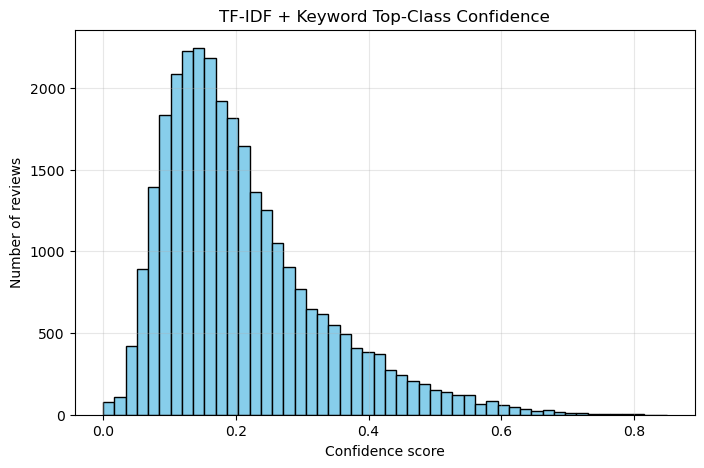

Confidence percentiles: [0.08547794 0.12292037 0.18133797 0.26452902 0.37624693]


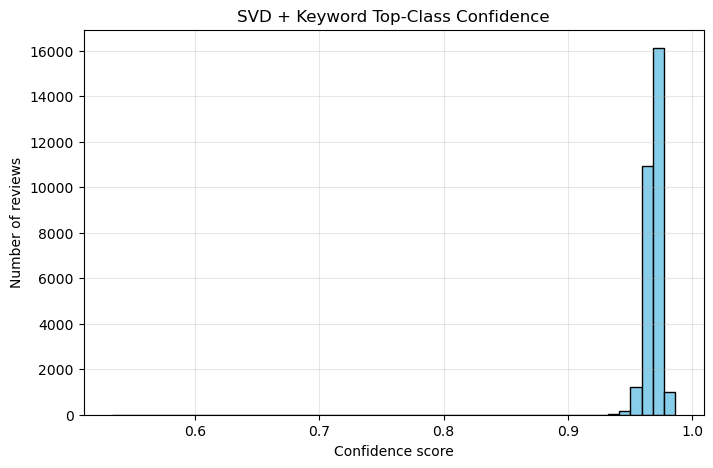

Confidence percentiles: [0.96203716 0.96581051 0.96922791 0.97234675 0.97505002]


'\n# BERT\nmax_conf_bert = plot_top_confidence_distribution(\n    similarity_matrix_bert, \n    title="BERT + Keyword Top-Class Confidence"\n)\n'

In [18]:
def plot_top_confidence_distribution(similarity_matrix, title="Top-Class Confidence Distribution", bins=50, percentiles=[10,25,50,75,90]):
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    max_conf_per_review = sim_dense.max(axis=1)

    plt.figure(figsize=(8,5))
    plt.hist(max_conf_per_review, bins=bins, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Confidence score")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    print("Confidence percentiles:", np.percentile(max_conf_per_review, percentiles))
    return max_conf_per_review

# TF-IDF
max_conf_tfidf = plot_top_confidence_distribution(
    similarity_matrix_tfidf, 
    title="TF-IDF + Keyword Top-Class Confidence"
)

# SVD
max_conf_svd = plot_top_confidence_distribution(
    similarity_matrix_svd, 
    title="SVD + Keyword Top-Class Confidence"
)
"""
# BERT
max_conf_bert = plot_top_confidence_distribution(
    similarity_matrix_bert, 
    title="BERT + Keyword Top-Class Confidence"
)
"""


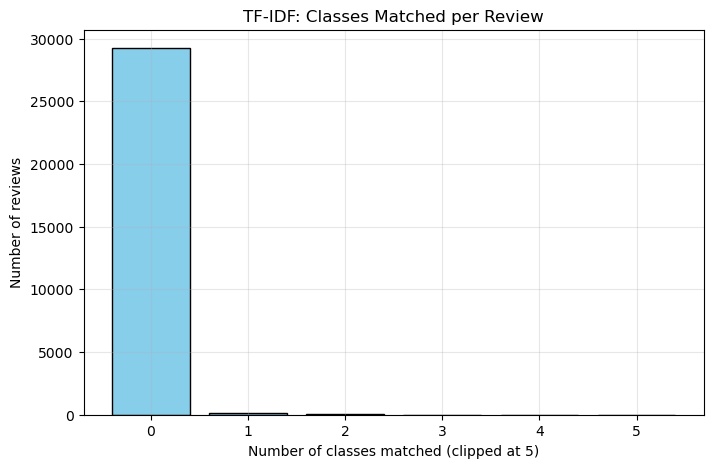

0 classes: 29250 reviews
1 classes: 152 reviews
2 classes: 81 reviews
3 classes: 4 reviews
4 classes: 0 reviews
5 classes: 0 reviews


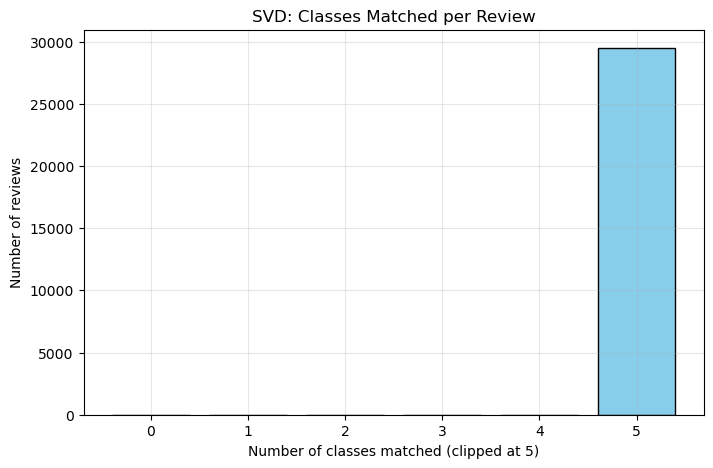

0 classes: 1 reviews
1 classes: 2 reviews
2 classes: 0 reviews
3 classes: 1 reviews
4 classes: 0 reviews
5 classes: 29483 reviews


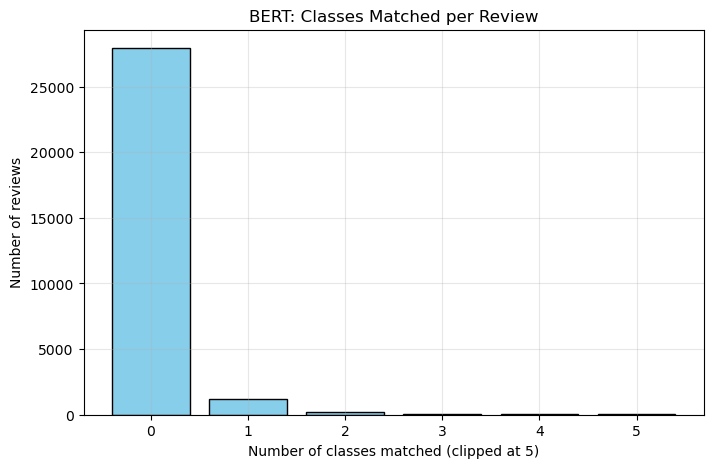

0 classes: 27933 reviews
1 classes: 1164 reviews
2 classes: 220 reviews
3 classes: 88 reviews
4 classes: 39 reviews
5 classes: 43 reviews


In [19]:
# How many classes per review
def plot_classes_per_review(similarity_matrix, min_conf=0.6, clip_max=5, title=None):
    if hasattr(similarity_matrix, "toarray"):
        sim_dense = similarity_matrix.toarray()
    else:
        sim_dense = similarity_matrix

    num_classes_per_review = (sim_dense >= min_conf).sum(axis=1)
    num_classes_per_review_clipped = np.clip(num_classes_per_review, 0, clip_max)

    counter = Counter(num_classes_per_review_clipped)
    counts = [counter.get(i, 0) for i in range(clip_max+1)]

    plt.figure(figsize=(8,5))
    plt.bar(range(clip_max+1), counts, color='skyblue', edgecolor='black')
    plt.xticks(range(clip_max+1))
    plt.title(title or f"Number of Classes per Review (conf >= {min_conf})")
    plt.xlabel(f"Number of classes matched (clipped at {clip_max})")
    plt.ylabel("Number of reviews")
    plt.grid(alpha=0.3)
    plt.show()

    for i, c in enumerate(counts):
        print(f"{i} classes: {c} reviews")

    return num_classes_per_review_clipped

# TF-IDF
num_classes_tfidf = plot_classes_per_review(
    similarity_matrix_tfidf, 
    min_conf=0.6, 
    clip_max=5, 
    title="TF-IDF: Classes Matched per Review"
)

# SVD
num_classes_svd = plot_classes_per_review(
    similarity_matrix_svd, 
    min_conf=0.6, 
    clip_max=5, 
    title="SVD: Classes Matched per Review"
)

# BERT
num_classes_bert = plot_classes_per_review(
    similarity_matrix_bert, 
    min_conf=0.6, 
    clip_max=5, 
    title="BERT: Classes Matched per Review"
)


# e. Embedding Table

In [20]:
# Class Embedding Table

CLASS_EMB_PATH = REPRESENTATION_PATH / "class_embeddings"
CLASS_EMB_PATH.mkdir(exist_ok=True)

class_vectorizer = TfidfVectorizer(max_features=5000)
class_vectorizer.fit(keyword_docs)
class_tfidf = class_vectorizer.transform(keyword_docs)



SVD_DIM_CLASS = 128
svd_class = TruncatedSVD(n_components=SVD_DIM_CLASS, n_iter=10, random_state=42)
class_dense = svd_class.fit_transform(class_tfidf)

def l2_normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

class_dense = l2_normalize_rows(class_dense)

np.save(CLASS_EMB_PATH / "class_embeddings.npy", class_dense)
with open(CLASS_EMB_PATH / "class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)
with open(CLASS_EMB_PATH / "class_vectorizer.pkl", "wb") as f:
    pickle.dump(class_vectorizer, f)
with open(CLASS_EMB_PATH / "svd_class_model.pkl", "wb") as f:
    pickle.dump(svd_class, f)

print(f"[DONE] Saved class embeddings for {len(class_names)} classes at {CLASS_EMB_PATH}")


[DONE] Saved class embeddings for 531 classes at project_release/representations/class_embeddings


# f. Silver Labels

## I. a, b & c

In [22]:
"""
# Reusable silver label generator function

def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)
    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)
    
    # Compute similarity matrix
    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)
    
    # Generate top-K silver labels
    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        top_indices = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes if top_classes else []))
        
    return silver_labels

# Load class embeddings
class_dense = np.load(CLASS_EMB_PATH / "class_embeddings.npy")
with open(CLASS_EMB_PATH / "class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

# Generate silver labels individually

# TF-IDF
silver_labels_tfidf_class = generate_silver_labels(train_tfidf.toarray(), class_dense, train_ids, class_names)

# SVD
silver_labels_svd_class = generate_silver_labels(train_dense, class_dense, train_ids, class_names)

# BERT
silver_labels_bert_class = generate_silver_labels(train_embeddings, class_dense, train_ids, class_names)


with open(SILVER_PATH / "silver_labels_tfidf_class.pkl", "wb") as f:
    pickle.dump(silver_labels_tfidf_class, f)

with open(SILVER_PATH / "silver_labels_svd_class.pkl", "wb") as f:
    pickle.dump(silver_labels_svd_class, f)

with open(SILVER_PATH / "silver_labels_bert_class.pkl", "wb") as f:
    pickle.dump(silver_labels_bert_class, f)
"""

'\n# Reusable silver label generator function\n\ndef generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):\n    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)\n    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)\n    \n    # Compute similarity matrix\n    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)\n    \n    # Generate top-K silver labels\n    silver_labels = []\n    for i, sims in enumerate(sim_matrix):\n        top_indices = sims.argsort()[::-1][:top_k]\n        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]\n        silver_labels.append((review_ids[i], top_classes if top_classes else []))\n        \n    return silver_labels\n\n# Load class embeddings\nclass_dense = np.load(CLASS_EMB_PATH / "class_embeddings.npy")\nwith open(CLASS_EMB_PATH / "class_nam

## II. Hybrid Labels

In [24]:
"""
TOP_K = 3
CONF_THRESH = 0.6
WEIGHTS = [0.3, 0.3, 0.4]  # TF-IDF, SVD, BERT

def generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):
    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)
    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)
    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)

    silver_labels = []
    for i, sims in enumerate(sim_matrix):
        top_indices = sims.argsort()[::-1][:top_k]
        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]
        silver_labels.append((review_ids[i], top_classes if top_classes else []))
    return silver_labels

silver_tfidf = generate_silver_labels(
    train_tfidf.toarray(), class_dense, train_ids, class_names, TOP_K, CONF_THRESH
)
silver_svd = generate_silver_labels(
    train_dense, class_dense, train_ids, class_names, TOP_K, CONF_THRESH
)
silver_bert = generate_silver_labels(
    train_embeddings, class_dense, train_ids, class_names, TOP_K, CONF_THRESH
)

final_hybrid_labels = []
for i in range(len(train_ids)):
    score_dict = defaultdict(float)
    for weight, silver_labels in zip(WEIGHTS, [silver_tfidf, silver_svd, silver_bert]):
        for cls, score in silver_labels[i][1]:
            score_dict[cls] += weight * score

    sorted_labels = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    final_hybrid_labels.append((train_ids[i], sorted_labels[:TOP_K]))

with open(SILVER_PATH / "silver_labels_hybrid.pkl", "wb") as f:
    pickle.dump(final_hybrid_labels, f)

print("[DONE] Generated final hybrid silver labels for all reviews.")
"""

'\nTOP_K = 3\nCONF_THRESH = 0.6\nWEIGHTS = [0.3, 0.3, 0.4]  # TF-IDF, SVD, BERT\n\ndef generate_silver_labels(review_embeddings, class_embeddings, review_ids, class_names, top_k=3, conf_thresh=0.6):\n    review_embeddings = review_embeddings / np.linalg.norm(review_embeddings, axis=1, keepdims=True)\n    class_embeddings = class_embeddings / np.linalg.norm(class_embeddings, axis=1, keepdims=True)\n    sim_matrix = cosine_similarity(review_embeddings, class_embeddings)\n\n    silver_labels = []\n    for i, sims in enumerate(sim_matrix):\n        top_indices = sims.argsort()[::-1][:top_k]\n        top_classes = [(class_names[idx], float(sims[idx])) for idx in top_indices if sims[idx] >= conf_thresh]\n        silver_labels.append((review_ids[i], top_classes if top_classes else []))\n    return silver_labels\n\nsilver_tfidf = generate_silver_labels(\n    train_tfidf.toarray(), class_dense, train_ids, class_names, TOP_K, CONF_THRESH\n)\nsilver_svd = generate_silver_labels(\n    train_dense,

# g. Review

In [26]:
"""
# Hybrid set visualized
def plot_hybrid_contributions(hybrid_labels, original_methods, method_weights=None, top_k=3):
    num_methods = len(original_methods)
    if method_weights is None:
        method_weights = [1.0] * num_methods
    method_names = ["TF-IDF", "SVD", "BERT"]

    contribution = defaultdict(float)
    for method_idx, method_labels in enumerate(original_methods):
        weight = method_weights[method_idx]
        for i in range(len(hybrid_labels)):
            hybrid_classes = set([cls for cls, _ in hybrid_labels[i][1][:top_k]])
            method_classes = set([cls for cls, _ in method_labels[i][1][:top_k]])
            contribution[method_idx] += len(hybrid_classes & method_classes) * weight

    total = sum(contribution.values())
    percentages = [100 * contribution[i] / total if total > 0 else 0.0 for i in range(num_methods)]

    plt.figure(figsize=(6, 6))
    plt.pie(percentages, labels=method_names, autopct="%1.1f%%", startangle=90,
            colors=['skyblue', 'lightgreen', 'salmon'])
    plt.title("Hybrid Label Method Contribution")
    plt.show()

    print("Hybrid Contribution:")
    for i, pct in enumerate(percentages):
        print(f"{method_names[i]}: {pct:.1f}%")

plot_hybrid_contributions(
    hybrid_labels=final_hybrid_labels,
    original_methods=[silver_tfidf, silver_svd, silver_bert],
    method_weights=WEIGHTS,
    top_k=TOP_K
)
"""

'\n# Hybrid set visualized\ndef plot_hybrid_contributions(hybrid_labels, original_methods, method_weights=None, top_k=3):\n    num_methods = len(original_methods)\n    if method_weights is None:\n        method_weights = [1.0] * num_methods\n    method_names = ["TF-IDF", "SVD", "BERT"]\n\n    contribution = defaultdict(float)\n    for method_idx, method_labels in enumerate(original_methods):\n        weight = method_weights[method_idx]\n        for i in range(len(hybrid_labels)):\n            hybrid_classes = set([cls for cls, _ in hybrid_labels[i][1][:top_k]])\n            method_classes = set([cls for cls, _ in method_labels[i][1][:top_k]])\n            contribution[method_idx] += len(hybrid_classes & method_classes) * weight\n\n    total = sum(contribution.values())\n    percentages = [100 * contribution[i] / total if total > 0 else 0.0 for i in range(num_methods)]\n\n    plt.figure(figsize=(6, 6))\n    plt.pie(percentages, labels=method_names, autopct="%1.1f%%", startangle=90,\n   

In [28]:
"""
with open(HYBRID_PATH / "silver_labels_hybrid.pkl", "rb") as f:
    final_hybrid_labels = pickle.load(f)

hierarchy_path = HIERARCHY_PATH
parents_map = defaultdict(list)

with open(hierarchy_path, "r", encoding="utf8") as f:
    for line in f:
        if "<" not in line:
            continue
        parent, child = [x.strip() for x in line.strip().split("<")]
        parents_map[child].append(parent)

def plot_label_distribution(silver_labels, top_n=20, title="Label Distribution"):
    all_labels = [cls for pid, labels in silver_labels for cls, _ in labels]
    counter = Counter(all_labels)
    top_items = counter.most_common(top_n)
    labels, counts = zip(*top_items) if top_items else ([], [])

    plt.figure(figsize=(12,5))
    plt.bar(labels, counts, color='skyblue')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()

def plot_labels_per_review(silver_labels, title="Labels per Review"):
    counts = [len(labels) for pid, labels in silver_labels]
    plt.figure(figsize=(6,4))
    plt.hist(counts, bins=range(0, max(counts)+2), color='salmon', edgecolor='black')
    plt.xlabel("Number of Labels")
    plt.ylabel("Number of Reviews")
    plt.title(title)
    plt.show()

def plot_confidence_scores(silver_labels, title="Label Confidence Distribution"):
    scores = [score for pid, labels in silver_labels for cls, score in labels]
    plt.figure(figsize=(6,4))
    plt.hist(scores, bins=30, color='lightgreen', edgecolor='black')
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

def compute_hierarchy_coverage(silver_labels, parents_map):
    total = 0
    covered_parents = set()
    for pid, labels in silver_labels:
        for cls, _ in labels:
            parents = parents_map.get(cls, [])
            covered_parents.update(parents)
            total += len(parents)
    print(f"Total parent links covered: {len(covered_parents)} / {total if total > 0 else 1}")

print("\n=== Diagnostics for Final Hybrid ===")
plot_label_distribution(
    final_hybrid_labels,
    top_n=20,
    title="Final Hybrid: Top-20 Label Distribution"
)
plot_labels_per_review(
    final_hybrid_labels,
    title="Final Hybrid: Labels per Review"
)
plot_confidence_scores(
    final_hybrid_labels,
    title="Final Hybrid: Confidence Score Distribution"
)
compute_hierarchy_coverage(
    final_hybrid_labels,
    parents_map
)
"""

'\nwith open(HYBRID_PATH / "silver_labels_hybrid.pkl", "rb") as f:\n    final_hybrid_labels = pickle.load(f)\n\nhierarchy_path = HIERARCHY_PATH\nparents_map = defaultdict(list)\n\nwith open(hierarchy_path, "r", encoding="utf8") as f:\n    for line in f:\n        if "<" not in line:\n            continue\n        parent, child = [x.strip() for x in line.strip().split("<")]\n        parents_map[child].append(parent)\n\ndef plot_label_distribution(silver_labels, top_n=20, title="Label Distribution"):\n    all_labels = [cls for pid, labels in silver_labels for cls, _ in labels]\n    counter = Counter(all_labels)\n    top_items = counter.most_common(top_n)\n    labels, counts = zip(*top_items) if top_items else ([], [])\n\n    plt.figure(figsize=(12,5))\n    plt.bar(labels, counts, color=\'skyblue\')\n    plt.xticks(rotation=90)\n    plt.title(title)\n    plt.show()\n\ndef plot_labels_per_review(silver_labels, title="Labels per Review"):\n    counts = [len(labels) for pid, labels in silver_

# 3 Baseline Multi-Label Classifier

As a baseline, we trained a simple multi-label text classifier using TF-IDF features and silver labels generated from keyword matching. The model is a feed-forward neural network with sigmoid outputs and binary cross-entropy loss, optimized using Adam and early stopping based on validation micro-F1. This baseline allows us to assess whether the automatically generated silver labels contain meaningful signal and establishes a reference point for future improvements such as pseudo-labeling or hierarchy-aware training.

In [29]:
# Relevant imports
import os
import csv
import copy
import random
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path
import numpy as np
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split

from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
import copy
from sklearn.metrics import f1_score
import torch
import torch.nn.functional as F

# Random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup initial filepaths
ROOT = Path("project_release")

TRAIN_CORPUS_PATH = ROOT / "Amazon_products" / "train" / "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "Amazon_products" / "test" / "test_corpus.txt"
SILVER_PATH = ROOT / "silver_labels"

SUBMISSION_PATH = ROOT / "submissions"
SUBMISSION_PATH.mkdir(exist_ok=True)

# Load Silver Labels
# Uncomment to use

# TF-IDF silver labels
with open(SILVER_PATH / "silver_labels_tfidf.pkl", "rb") as f:
    silver_labels = pickle.load(f)

# SVD silver labels
#with open(SILVER_PATH / "silver_labels_svd.pkl", "rb") as f:
#    silver_labels = pickle.load(f)

# BERT silver labels
#with open(SILVER_PATH / "silver_labels_bert.pkl", "rb") as f:
#    silver_labels = pickle.load(f)
    
# Hybrid silver labels
# with open(SILVER_PATH / "silver_labels_hybrid.pkl", "rb") as f:
#     silver_labels = pickle.load(f)


In [30]:
with open(TRAIN_CORPUS_PATH, "r", encoding="utf8") as f:
    train_texts = [line.strip() for line in f]

label_set = sorted({cls for _, labels in silver_labels for cls, _ in labels})
label_to_idx = {lbl: i for i, lbl in enumerate(label_set)}
num_labels = len(label_set)

y = np.zeros((len(train_texts), num_labels), dtype=np.float32)
for i, (_, labels) in enumerate(silver_labels):
    for cls, _ in labels:
        y[i, label_to_idx[cls]] = 1.0

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(train_texts).toarray().astype(np.float32)

class SilverDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],
            "y": self.y[idx]
        }

dataset = SilverDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = MLP(X.shape[1], num_labels).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [31]:
# ---------- Training loop ----------
EPOCHS = 10
patience = 5
best_val_f1 = -1
patience_counter = 0
best_model_state = None

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        X, y = batch["X"].to(device), batch["y"].to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # ---------- Validation ----------
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            X, y = batch["X"].to(device), batch["y"].to(device)
            logits = model(X)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu().int())

    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    val_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    print(f"[VAL] f1_micro: {val_f1:.4f}")

    # ---------- Early stopping ----------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("[Early Stopping] No improvement.")
        break

# Save best model
torch.save(best_model_state, SILVER_PATH / "last_best.pth")
print("[DONE] Training complete. Best f1_micro:", best_val_f1)


[Epoch 1] Train Loss: 0.0453
[VAL] f1_micro: 0.0000
[Epoch 2] Train Loss: 0.0011
[VAL] f1_micro: 0.0000
[Epoch 3] Train Loss: 0.0010
[VAL] f1_micro: 0.0952
[Epoch 4] Train Loss: 0.0008
[VAL] f1_micro: 0.1818
[Epoch 5] Train Loss: 0.0006
[VAL] f1_micro: 0.2979
[Epoch 6] Train Loss: 0.0005
[VAL] f1_micro: 0.2418
[Epoch 7] Train Loss: 0.0004
[VAL] f1_micro: 0.2766
[Epoch 8] Train Loss: 0.0003
[VAL] f1_micro: 0.2340
[Epoch 9] Train Loss: 0.0002
[VAL] f1_micro: 0.2526
[Epoch 10] Train Loss: 0.0002
[VAL] f1_micro: 0.2340
[Early Stopping] No improvement.
[DONE] Training complete. Best f1_micro: 0.2978723404255319


In [33]:
model.load_state_dict(torch.load(SILVER_PATH / "last_best.pth", map_location=device))
model.eval()

with open(TEST_CORPUS_PATH, "r", encoding="utf8") as f:
    pid_text_pairs = []
    for line in f:
        pid, text = line.strip().split("\t", 1)
        pid_text_pairs.append((pid, text))

test_pids = [p for p, _ in pid_text_pairs]
test_texts = [t for _, t in pid_text_pairs]

X_test = vectorizer.transform(test_texts).toarray().astype(np.float32)
X_test = torch.from_numpy(X_test).to(device)

idx_to_label = {v: k for k, v in label_to_idx.items()}

all_preds = []
with torch.no_grad():
    for i in range(0, len(X_test), 256):
        logits = model(X_test[i:i+256])
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).cpu().numpy()
        all_preds.append(preds)

all_preds = np.vstack(all_preds)

submission_rows = []
for pid, pred_vec in zip(test_pids, all_preds):
    label_indices = np.where(pred_vec == 1)[0]
    if len(label_indices) == 0:
        label_indices = [int(np.argmax(pred_vec))]
    submission_rows.append(
        (pid, ",".join(str(idx) for idx in sorted(label_indices)))
    )

submission_file = SUBMISSION_PATH / "submission.csv"
with open(submission_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "labels"])
    for row in submission_rows:
        writer.writerow(row)

print(f"[DONE] Submission saved to {submission_file}")
print(f"Total samples: {len(submission_rows)}")


[DONE] Submission saved to project_release/submissions/submission.csv
Total samples: 19658
